<a href="https://colab.research.google.com/github/Taiphong2006/BaiTapAI/blob/Bai1/B%C3%A0i_T%E1%BA%ADp_Nh%C3%B3m_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!git init


Reinitialized existing Git repository in /content/.git/


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB
None

Số lượng giá trị thiếu ở mỗi cột:
fixed acidity           0
volatile acidity        0
citric acid             0
residual

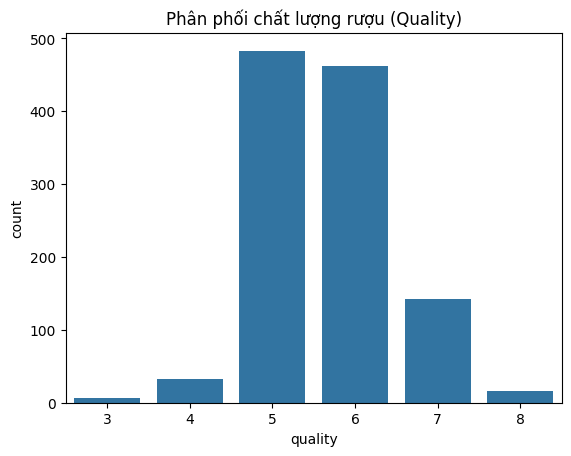

Kích thước tập Train: (914, 11), Tập Test: (229, 11)
Độ chính xác của mô hình: 71.18%

Báo cáo phân lớp chi tiết:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.73      0.86      0.79        97
           6       0.69      0.72      0.70        92
           7       0.70      0.48      0.57        29
           8       0.00      0.00      0.00         3

    accuracy                           0.71       229
   macro avg       0.35      0.34      0.34       229
weighted avg       0.68      0.71      0.69       229



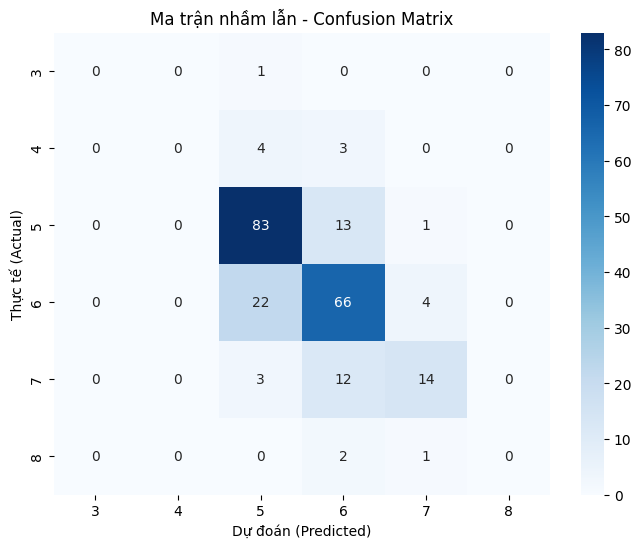

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Chất lượng rượu được dự đoán là: 5
Iteration 1, loss = 2.03723216
Iteration 2, loss = 1.85949853
Iteration 3, loss = 1.71291021
Iteration 4, loss = 1.59410075
Iteration 5, loss = 1.49066653
Iteration 6, loss = 1.40087853
Iteration 7, loss = 1.32329669
Iteration 8, loss = 1.25857380
Iteration 9, loss = 1.20458103
Iteration 10, loss = 1.16300368
Iteration 11, loss = 1.12813957
Iteration 12, loss = 1.09927379
Iteration 13, loss = 1.07302695
Iteration 14, loss = 1.05236962
Iteration 15, loss = 1.03379239
Iteration 16, loss = 1.01795559
Iteration 17, loss = 1.00522452
Iteration 18, loss = 0.99321118
Iteration 19, loss = 0.98344142
Iteration 20, loss = 0.97530500
Iteration 21, loss = 0.96604431
Iteration 22, loss = 0.95900666
Iteration 23, loss = 0.95264777
Iteration 24, loss = 0.94711696
Iteration 25, loss = 0.94072850
Iteration 26, loss = 0.93556069
Iteration 27, loss = 0.93015227
Iteration 28, loss = 0.92507530
Iteration 29, loss = 0.92014944
Iteration 30, loss = 0.91581816
Iteration 31, 

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42,
              verbose=True)

In [7]:
# Import các thư viện cơ bản
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Đọc file dữ liệu
df = pd.read_csv('WineQT.csv')

# Xem 5 dòng đầu tiên để kiểm tra
df.head()

# 1. Kiểm tra thông tin tổng quan (kiểu dữ liệu, số lượng dòng/cột)
print(df.info())

# 2. Kiểm tra xem có dữ liệu bị khuyết (NaN/Null) không
print("\nSố lượng giá trị thiếu ở mỗi cột:")
print(df.isnull().sum())

# 3. Xem thống kê mô tả (mean, min, max,...)
print(df.describe())

# 4. Kiểm tra phân phối của biến mục tiêu 'quality'
sns.countplot(x='quality', data=df)
plt.title('Phân phối chất lượng rượu (Quality)')
plt.show()

# 5. Loại bỏ cột không cần thiết (nếu trong file của bạn có cột 'Id' như một số tập WineQT)
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])


# Tách đặc trưng (features) và nhãn (target)
X = df.drop(columns=['quality'])
y = df['quality']

# Chia dữ liệu theo tỷ lệ 80% Train - 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(# Kích thước các tập dữ liệu ban đầu
f"Kích thước tập Train: {X_train.shape}, Tập Test: {X_test.shape}")



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.ensemble import RandomForestClassifier

# Khởi tạo mô hình
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Huấn luyện mô hình trên dữ liệu đã chuẩn hóa
model.fit(X_train_scaled, y_train)

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Dự đoán trên tập dữ liệu test
y_pred = model.predict(X_test_scaled)

# 1. Tính độ chính xác tổng thể (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Độ chính xác của mô hình: {accuracy * 100:.2f}%\n")

# 2. In báo cáo chi tiết (Precision, Recall, F1-score cho từng mức chất lượng)
print("Báo cáo phân lớp chi tiết:")
print(classification_report(y_test, y_pred, zero_division=0))

# 3. Trực quan hóa Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán (Predicted)')
plt.title('Ma trận nhầm lẫn - Confusion Matrix')
plt.show()

# Tạo thử một mẫu rượu mới với các thông số (phải đúng số lượng và thứ tự cột giống X)
# Ví dụ lấy giá trị trung bình của tập dữ liệu để thử nghiệm
sample_wine = [[7.4, 0.70, 0.00, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]]

# Đừng quên phải chuẩn hóa mẫu thử này bằng scaler đã fit ở Bước 4
sample_scaled = scaler.transform(sample_wine)

# Dự đoán chất lượng
predicted_quality = model.predict(sample_scaled)
print(f"Chất lượng rượu được dự đoán là: {predicted_quality[0]}")

from sklearn.neural_network import MLPClassifier

# Thêm tham số verbose=True vào cuối
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    verbose=True  # <--- BẮT BUỘC PHẢI CÓ DÒNG NÀY
)

# Tiến hành huấn luyện
mlp_model.fit(X_train_scaled, y_train)